# Eksperiment 2-7 - Razlika formi SMA(3)

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from experiment_utils import run_one_experiment,save_result_v1,run, MLPClassifier

import warnings
warnings.filterwarnings('ignore')

## Podaci

In [3]:
df = pd.read_csv('../data/Processed_Project_Data/fifa_and_elo_rankings_clean_filled.csv')
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df['date'] = pd.to_datetime(df['date'], format='mixed')
df = df.sort_values('date').reset_index(drop=True)

print(f'Ukupno meceva: {len(df)}')
print(df['result'].value_counts())

Ukupno meceva: 1239
result
 1    582
-1    371
 0    286
Name: count, dtype: int64


## SMA(3) i razlika formi

In [4]:
home_rows = df[['date', 'home_team', 'result']].rename(columns={'home_team': 'team', 'result': 'team_result'})
away_rows = df[['date', 'away_team', 'result']].copy()
away_rows['team_result'] = -away_rows['result']
away_rows = away_rows[['date', 'away_team', 'team_result']].rename(columns={'away_team': 'team'})

team_results = pd.concat([home_rows, away_rows]).sort_values('date').reset_index(drop=True)
team_results['sma3'] = (
    team_results.groupby('team')['team_result']
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

df = df.merge(team_results.rename(columns={'team': 'home_team', 'sma3': 'home_form_sma3'})[['date', 'home_team', 'home_form_sma3']], on=['date', 'home_team'], how='left')
df = df.merge(team_results.rename(columns={'team': 'away_team', 'sma3': 'away_form_sma3'})[['date', 'away_team', 'away_form_sma3']], on=['date', 'away_team'], how='left')
df = df.dropna(subset=['home_form_sma3', 'away_form_sma3']).reset_index(drop=True)

df['form_diff_sma3'] = df['home_form_sma3'] - df['away_form_sma3']
print(f'Meceva nakon filtriranja: {len(df)}')

Meceva nakon filtriranja: 847


## Priprema i pokretanje

In [5]:
X = df[['form_diff_sma3']].values
le = LabelEncoder()
y = le.fit_transform(df['result'].values)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_train_t = torch.tensor(y_train,    dtype=torch.long)
X_test_t  = torch.tensor(X_test_sc,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,     dtype=torch.long)

In [6]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_t.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 1.0055 | val loss = 0.9517 | val acc = 0.6103
Epoch 100/1000 | train loss = 1.0113 | val loss = 0.9594 | val acc = 0.6103
Epoch 150/1000 | train loss = 1.0099 | val loss = 0.9608 | val acc = 0.5588
Epoch 200/1000 | train loss = 1.0106 | val loss = 0.9530 | val acc = 0.5588
Epoch 250/1000 | train loss = 1.0088 | val loss = 0.9583 | val acc = 0.5588
Epoch 300/1000 | train loss = 1.0056 | val loss = 0.9651 | val acc = 0.5588
Epoch 350/1000 | train loss = 1.0084 | val loss = 0.9620 | val acc = 0.5588
Epoch 400/1000 | train loss = 1.0115 | val loss = 0.9630 | val acc = 0.5588
Epoch 450/1000 | train loss = 1.0094 | val loss = 0.9625 | val acc = 0.5588
Epoch 500/1000 | train loss = 1.0037 | val loss = 0.9635 | val acc = 0.5588
Epoch 550/1000 | train loss = 1.0057 | val loss = 0.9706 | val acc = 0.5588
Epoch 600/1000 | train loss = 1.0010 | val loss = 0.9613 | val acc = 0.5588
Epoch 650/1000 | train loss = 0.9986 | val loss = 0.9620 | val acc = 0.5588
Epoch 700/100

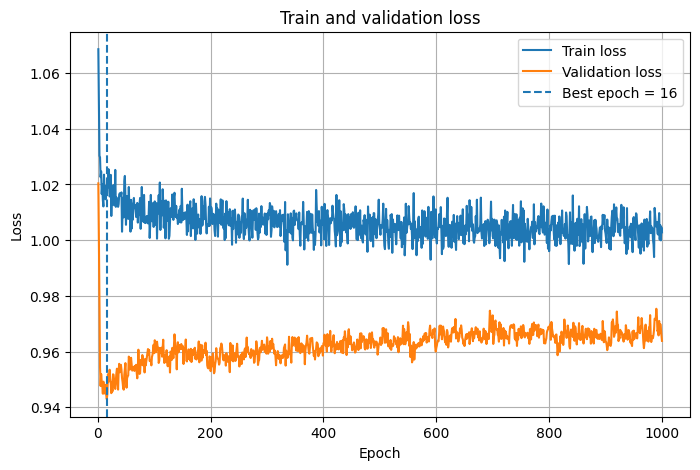

0.5764705882352941

In [7]:
run_one_experiment(model, criterion, optimizer, X_train_t, y_train_t, X_test_t, y_test_t)

In [8]:
best_num_epochs = 16

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_t,
    y_train_tensor=y_train_t,
    X_test_tensor=X_test_t,
    y_test_tensor=y_test_t,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.5765 | Precision: 0.3662 | Recall: 0.4792 | Specificity: 0.7559 | F1: 0.4142

Run 2/10
Accuracy: 0.5765 | Precision: 0.3662 | Recall: 0.4792 | Specificity: 0.7559 | F1: 0.4142

Run 3/10
Accuracy: 0.5765 | Precision: 0.3662 | Recall: 0.4792 | Specificity: 0.7559 | F1: 0.4142

Run 4/10
Accuracy: 0.5765 | Precision: 0.3662 | Recall: 0.4792 | Specificity: 0.7559 | F1: 0.4142

Run 5/10
Accuracy: 0.6000 | Precision: 0.3857 | Recall: 0.4622 | Specificity: 0.7455 | F1: 0.4129

Run 6/10
Accuracy: 0.6000 | Precision: 0.3857 | Recall: 0.4622 | Specificity: 0.7455 | F1: 0.4129

Run 7/10
Accuracy: 0.6000 | Precision: 0.3857 | Recall: 0.4622 | Specificity: 0.7455 | F1: 0.4129

Run 8/10
Accuracy: 0.6000 | Precision: 0.3857 | Recall: 0.4622 | Specificity: 0.7455 | F1: 0.4129

Run 9/10
Accuracy: 0.6000 | Precision: 0.3857 | Recall: 0.4622 | Specificity: 0.7455 | F1: 0.4129

Run 10/10
Accuracy: 0.5765 | Precision: 0.3662 | Recall: 0.4792 | Specificity: 0.7559 | F1: 0.4142

Summary o

In [9]:
save_result_v1(
    experiment_name="Experiment_2-7_SMA3_diff",
    summary=summary
)


Saved result for Experiment_2-7_SMA3_diff
File: ../results/experiment_summary_v1.csv
